# Exploratory Data Analysis

Explore the two processed churn datasets **individually**: Olist (Brazilian e-commerce) and Labeled (subscription churn). We analyze distributions, churn rates by segment, and key drivers for each. Run **00_data_preprocessing** first so `data/processed/olist_churn_features.csv` and `data/processed/labeled_churn_features.csv` exist.

| Source | Churn = 1 means |
|--------|------------------|
| **Olist** (Brazilian e-commerce) | No purchase in the **last 90+ days** (inactive), **or** average review score **&lt; 2** (very dissatisfied). So: "has not bought recently" or "very unhappy." |
| **Labeled** (subscription dataset) | Customer **cancelled or paused** their subscription. So: they ended or paused the relationship. |

## 1. Load data and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
olist = pd.read_csv(DATA_PROCESSED / "olist_churn_features.csv")
labeled = pd.read_csv(DATA_PROCESSED / "labeled_churn_features.csv")
print("Olist shape:", olist.shape)
print("Labeled shape:", labeled.shape)
print("\nOlist (head):")
display(olist.head())
print("\nLabeled (head):")
display(labeled.head())

Olist shape: (96096, 8)
Labeled shape: (2000, 7)

Olist (head):


,customer_id,recency,tenure_days,frequency,monetary,avg_review,churn,source
0,0000366f3b9a7992bf8c76cfdf3221e2,160,160,1,141.90,5.0,1,Olist
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,163,1,27.19,4.0,1,Olist
2,0000f46a3911fa3c0805444483337064,585,585,1,86.22,3.0,1,Olist
3,0000f6ccb0745a6a4b88665a16c9f078,369,369,1,43.62,4.0,1,Olist
4,0004aac84e0df4da2b147fca70cf8255,336,336,1,196.89,5.0,1,Olist



Labeled (head):


,customer_id,recency,tenure_days,frequency,monetary,churn,source
0,CUST1000,911,1686,37,391.05,0,Labeled
1,CUST1001,1351,1766,35,512.16,0,Labeled
2,CUST1002,716,802,44,1208.28,1,Labeled
3,CUST1003,547,752,1,338.64,1,Labeled
4,CUST1004,340,1715,35,438.62,0,Labeled


## 2. Overview: dtypes, describe, missing values

In [2]:
print("Olist dtypes:")
print(olist.dtypes)
print("\nLabeled dtypes:")
print(labeled.dtypes)

Olist dtypes:
customer_id     object
recency          int64
tenure_days      int64
frequency        int64
monetary       float64
avg_review     float64
churn            int64
source          object
dtype: object

Labeled dtypes:
customer_id     object
recency          int64
tenure_days      int64
frequency        int64
monetary       float64
churn            int64
source          object
dtype: object


In [3]:
print("Olist — describe:")
display(olist.describe())
print("\nLabeled — describe:")
display(labeled.describe())

Olist — describe:


,recency,tenure_days,frequency,monetary,avg_review,churn
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,287.735691,290.458552,1.034809,166.592492,4.084963,0.907655
std,153.414676,153.903666,0.214384,231.428332,1.336654,0.289514
min,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,163.000000,166.000000,1.000000,63.120000,4.000000,1.000000
50%,268.000000,272.000000,1.000000,108.000000,5.000000,1.000000
75%,397.000000,400.000000,1.000000,183.530000,5.000000,1.000000
max,772.000000,772.000000,17.000000,13664.080000,5.000000,1.000000



Labeled — describe:


,recency,tenure_days,frequency,monetary,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,630.225000,1285.946500,25.158000,1025.845325,0.398000
std,410.964947,313.306412,14.158752,560.793690,0.489608
min,0.000000,731.000000,1.000000,22.290000,0.000000
25%,284.000000,1016.000000,13.000000,551.937500,0.000000
50%,585.000000,1299.000000,25.000000,1057.230000,0.000000
75%,906.000000,1557.250000,37.000000,1494.682500,1.000000
max,1795.000000,1826.000000,49.000000,1998.080000,1.000000


In [4]:
print("Olist — missing values:")
print(olist.isna().sum())
print("\nLabeled — missing values:")
print(labeled.isna().sum())

Olist — missing values:
customer_id    0
recency        0
tenure_days    0
frequency      0
monetary       0
avg_review     0
churn          0
source         0
dtype: int64

Labeled — missing values:
customer_id    0
recency        0
tenure_days    0
frequency      0
monetary       0
churn          0
source         0
dtype: int64


## 3. Churn rate (per dataset)

In [5]:
print("Olist — churn rate:", olist["churn"].mean().round(3), "| sum:", olist["churn"].sum(), "| count:", len(olist))
display(olist["churn"].agg(["mean", "sum", "count"]).to_frame("Olist").T)
print("\nLabeled — churn rate:", labeled["churn"].mean().round(3), "| sum:", labeled["churn"].sum(), "| count:", len(labeled))
display(labeled["churn"].agg(["mean", "sum", "count"]).to_frame("Labeled").T)

Olist — churn rate: 0.908 | sum: 87222 | count: 96096


,mean,sum,count
Olist,0.907655,87222.0,96096.0



Labeled — churn rate: 0.398 | sum: 796 | count: 2000


,mean,sum,count
Labeled,0.398,796.0,2000.0


## 4. Distributions of key features

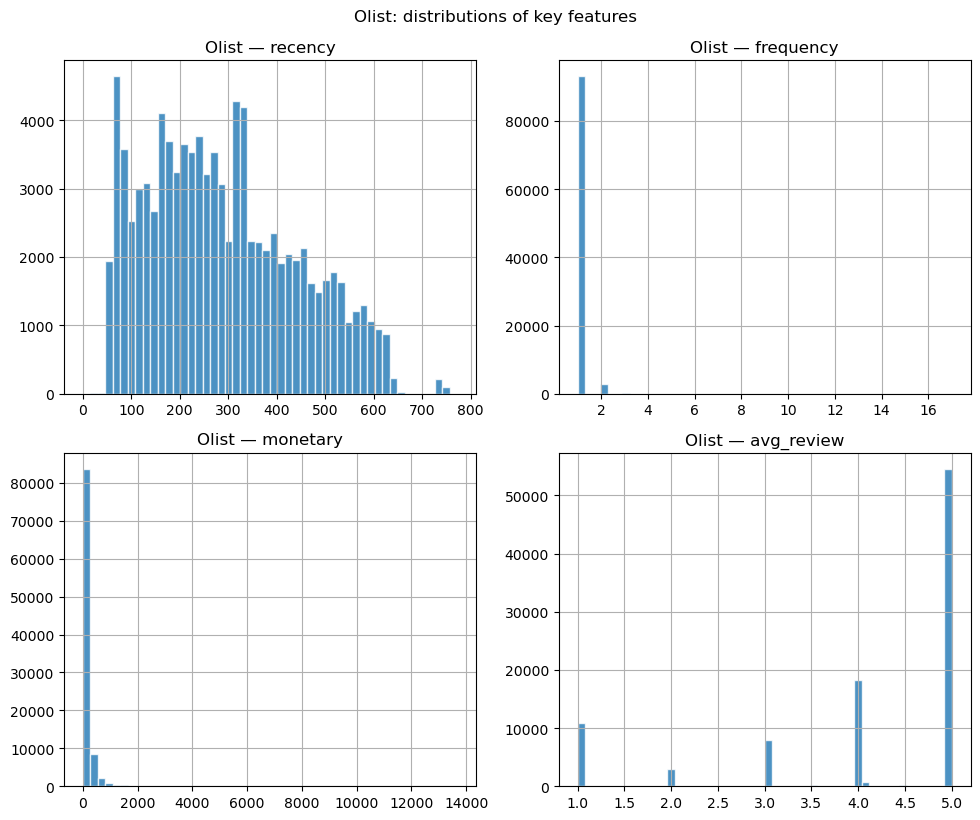

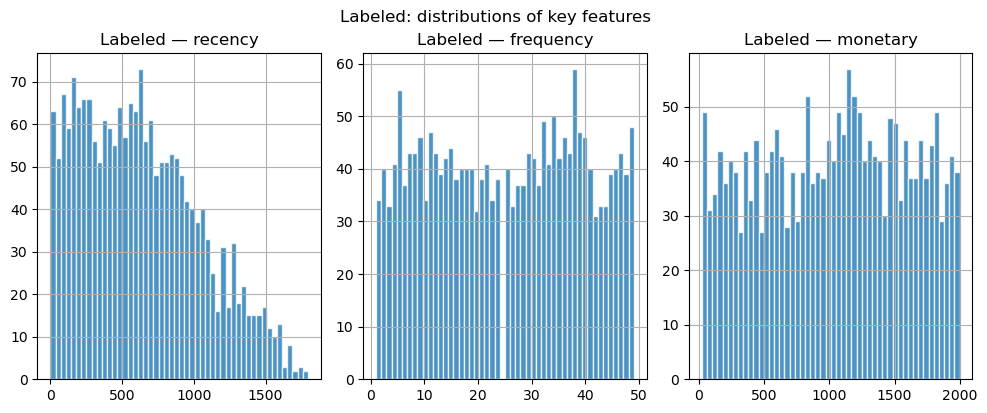

In [6]:
# Olist: recency, frequency, monetary, avg_review
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ["recency", "frequency", "monetary", "avg_review"]):
    olist[col].hist(ax=ax, bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"Olist — {col}")
plt.tight_layout()
plt.suptitle("Olist: distributions of key features", y=1.02)
plt.show()

# Labeled: recency, frequency, monetary (no avg_review)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, col in zip(axes.flat, ["recency", "frequency", "monetary"]):
    labeled[col].hist(ax=ax, bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"Labeled — {col}")
plt.tight_layout()
plt.suptitle("Labeled: distributions of key features", y=1.02)
plt.show()

## 5. Churn vs features (recency bins for both; satisfaction/avg_review for Olist only)

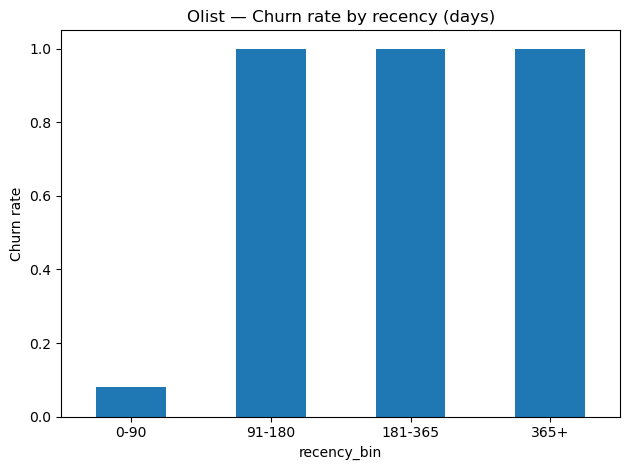

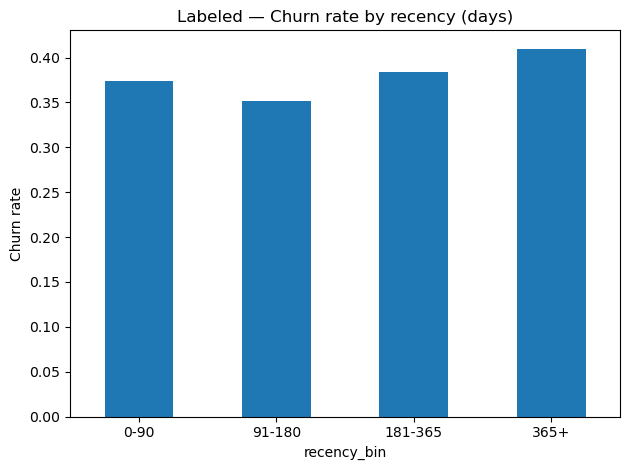

In [7]:
# Churn rate by recency bins — Olist
olist["recency_bin"] = pd.cut(olist["recency"], bins=[0, 90, 180, 365, olist["recency"].max() + 1], labels=["0-90", "91-180", "181-365", "365+"])
churn_recency_olist = olist.groupby("recency_bin", observed=True)["churn"].mean()
churn_recency_olist.plot(kind="bar", title="Olist — Churn rate by recency (days)")
plt.ylabel("Churn rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Churn rate by recency bins — Labeled
labeled["recency_bin"] = pd.cut(labeled["recency"], bins=[0, 90, 180, 365, labeled["recency"].max() + 1], labels=["0-90", "91-180", "181-365", "365+"])
churn_recency_labeled = labeled.groupby("recency_bin", observed=True)["churn"].mean()
churn_recency_labeled.plot(kind="bar", title="Labeled — Churn rate by recency (days)")
plt.ylabel("Churn rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

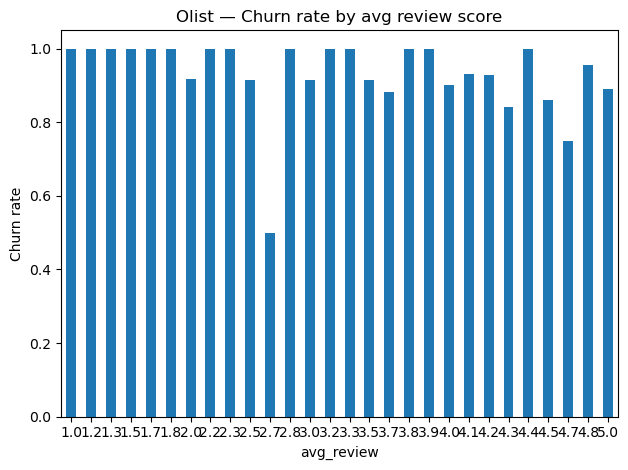

In [8]:
# Churn rate by avg_review (Olist only; Labeled has no review data)
olist.groupby(olist["avg_review"].round(1))["churn"].mean().plot(kind="bar", title="Olist — Churn rate by avg review score")
plt.ylabel("Churn rate")
plt.xlabel("avg_review")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Correlations (numeric features vs churn)

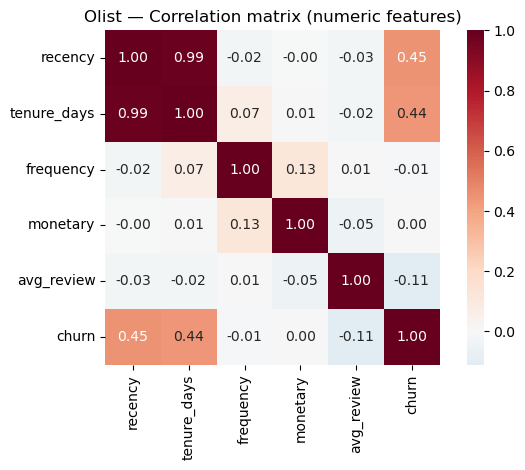

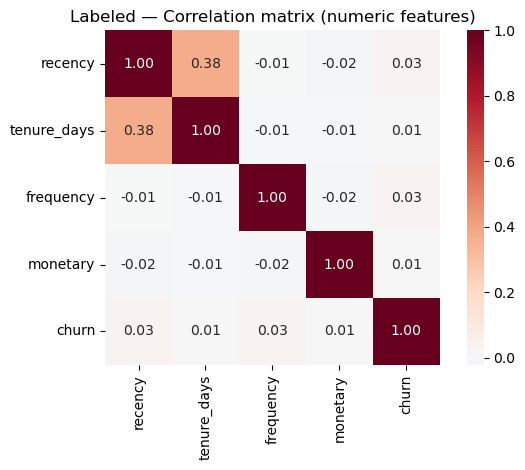

In [9]:
# Olist: includes avg_review
numeric_olist = ["recency", "tenure_days", "frequency", "monetary", "avg_review", "churn"]
corr_olist = olist[numeric_olist].corr()
sns.heatmap(corr_olist, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Olist — Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

# Labeled: no avg_review
numeric_labeled = ["recency", "tenure_days", "frequency", "monetary", "churn"]
corr_labeled = labeled[numeric_labeled].corr()
sns.heatmap(corr_labeled, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Labeled — Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()